In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA




Vamos fazer isto de forma diferente. Estava a abordar mal a coisa, e os resultados não estavam a ser bons. Já percebi o que fazer e como fazer.

In [2]:
dataset = pd.read_csv('Pokemon.csv', index_col = 0)

dataset.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [3]:
dataset.isna().sum()

Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [4]:
dataset_num = dataset.select_dtypes(include= 'number')
dataset_cat = dataset.select_dtypes(exclude = 'number')

dataset_num.head()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
#,,,,,,,,
1,318,45,49,49,65,65,45,1
2,405,60,62,63,80,80,60,1
3,525,80,82,83,100,100,80,1
3,625,80,100,123,122,120,80,1
4,309,39,52,43,60,50,65,1


In [5]:
scaler = StandardScaler()

num_scaled = scaler.fit_transform(dataset_num) #this returns by itself an array

#we need to put it as a dataframe so that we can merge with the categorical data
num_scaled = pd.DataFrame(num_scaled, columns=dataset_num.columns, index = dataset.index)


dataset_scaled = pd.concat([dataset_cat, num_scaled], axis=1)

In [6]:
num_scaled.drop(['Total', 'Generation'], axis = 1, inplace=True)


In [7]:
k_range = range(2,25)

dispersion = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(num_scaled)
    dispersion.append(kmeans.inertia_)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\c

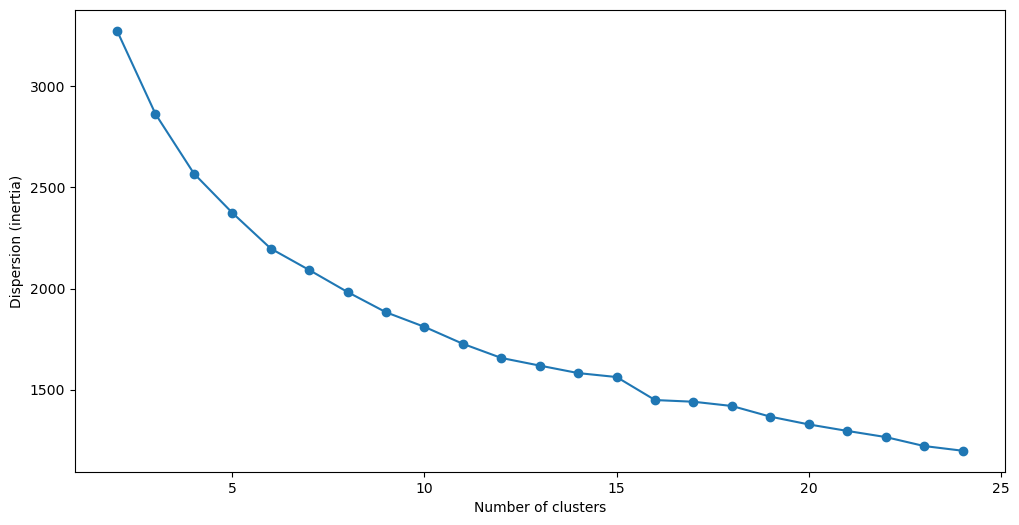

In [8]:
plt.figure(figsize=(12,6))
plt.plot(k_range, dispersion, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Dispersion (inertia)')
plt.show()

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\c

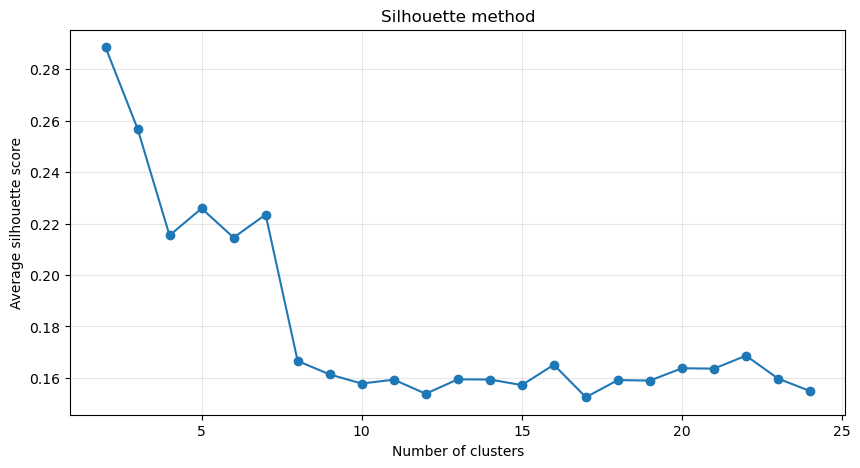

In [9]:

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(num_scaled)
    score = silhouette_score(num_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Average silhouette score')
plt.title('Silhouette method')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
for k in [2, 3, 4]:


c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [11]:
dataset.groupby("cluster")[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].mean()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
cluster,,,,,,
0,79.732510,100.777778,78.514403,101.975309,85.979424,99.995885
1,52.227405,56.571429,53.641399,52.055394,51.997085,54.034985
2,84.663551,90.224299,100.915888,72.995327,87.822430,55.088785


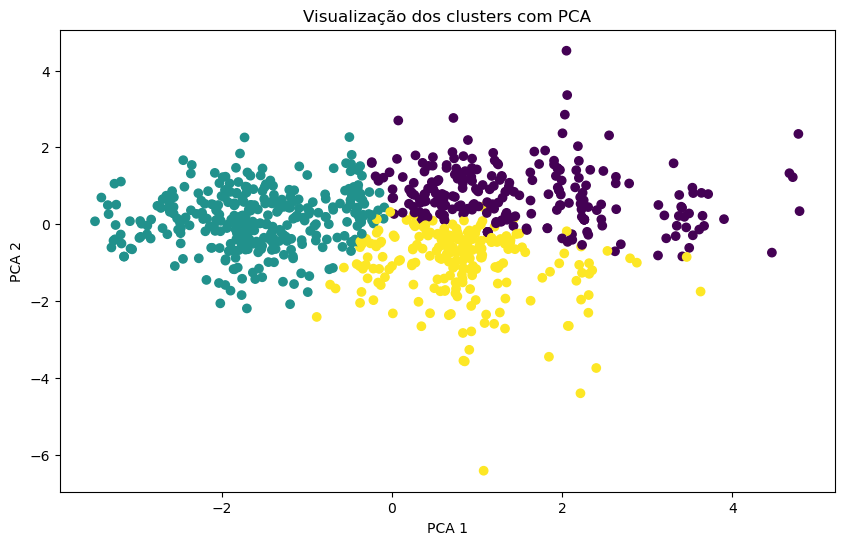

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(num_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualização dos clusters com PCA')
plt.show()